# **Question 1:**

**A. What visit types are most common for thyroid-related care?**

**B. Are certain thyroid diagnosis more likely to appear in specific visit types?**

## Python Script 1: Importing the Required Data

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Import required csv files
visits_thyroid = pd.read_csv("visits_analysis_ready.csv")

In [5]:
# Verify data integrity
visits_thyroid.head()

,person_id,gender_concept_id,gender,gender_clean,year_of_birth,age_at_visit,age_group,race,race_clean,ethnicity,...,visit_start_date,visit_end_date,visit_duration_days,same_day_visit_flag,long_visit_flag_7d,long_visit_flag_30d,office_related_flag,inpatient_related_flag,emergency_related_flag,telehealth_flag
0,924609883,8532,F,F,1956.0,69.0,65+,White,White,Not Hispanic or Latino,...,2025-11-21,2026-01-18,58.0,0,1,1,1,0,0,0
1,426015508,8532,F,F,1932.0,93.0,65+,White,White,Not Hispanic or Latino,...,2025-08-01,2025-08-03,2.0,0,0,0,1,0,0,0
2,178569665,8532,F,F,1979.0,46.0,35-49,Black or African American,Black or African American,Not Hispanic or Latino,...,2025-05-15,2025-06-08,24.0,0,1,0,0,0,0,1
3,749236674,8507,M,M,1964.0,61.0,50-64,White,White,Not Hispanic or Latino,...,2025-08-19,2025-09-20,32.0,0,1,1,1,0,0,0
4,82232424,8532,F,F,1994.0,31.0,18-34,Other,Other,Not Hispanic or Latino,...,2025-06-10,2025-08-23,74.0,0,1,1,1,0,0,0


In [6]:
# Verify columns
visits_thyroid.columns

Index(['person_id', 'gender_concept_id', 'gender', 'gender_clean',
       'year_of_birth', 'age_at_visit', 'age_group', 'race', 'race_clean',
       'ethnicity', 'ethnicity_clean', 'snomed_condition_concept_id',
       'condition_description', 'condition_description_clean',
       'visit_concept_id', 'visit_type', 'visit_type_clean',
       'visit_type_group', 'visit_start_date', 'visit_end_date',
       'visit_duration_days', 'same_day_visit_flag', 'long_visit_flag_7d',
       'long_visit_flag_30d', 'office_related_flag', 'inpatient_related_flag',
       'emergency_related_flag', 'telehealth_flag'],
      dtype='str')

In [7]:
# Verify length of data
len(visits_thyroid)

179124

## **Question 1A: What visit types are most common for thyroid-related care?**
### **Python Script 2:**
- This script provides which `visit type` are the most common from the thyroid population by obtaining the total counts for each `visit type`
- We will create a frequency table where we have 3 main columns: `Visit Type`, `Count`, and `Percent` (rounded by 2 decimals)

In [ ]:
# Displays total visit type count for all thyroid-related cases in a frequency table into 2 main columns: Visit Type & Count
visit_type_count = visits_thyroid["visit_type_group"].str.lower().str.strip().value_counts()

visit_type_table = visit_type_count.reset_index()
visit_type_table.columns = ["Visit Type", "Count"]

# Displays the Visit Type Frequency Table by converting the data into percentages rounded by 2 decimals
# Adds a "percent" column to display percentages for each visit type

visit_type_table["Percent"] = (visit_type_table["Count"] / visit_type_table["Count"].sum() * 100).round(2)
visit_type_table["Percent"] = visit_type_table["Percent"].astype(str) + "%"

visit_type_table["Visit Type"] = visit_type_table["Visit Type"].str.title()

visit_type_table

,Visit Type,Count,Percent
0,Office/Outpatient,132319,73.87%
1,Emergency-Related,23120,12.91%
2,Inpatient-Related,11533,6.44%
3,Telehealth,6117,3.41%
4,Case Management,6035,3.37%


## Matplotlib: Most Common Visit Types for Thyroid-Related Care Bar Graph
- We used matplotlib to plot the desired data
- We'll plot:
    - A bar graph to display the most common `visit types` for thyroid-related care

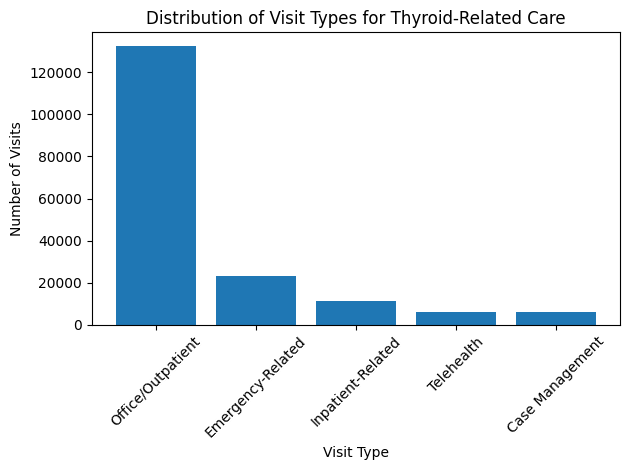

In [14]:
# Creates a Bar Graph to display results
plt.bar(visit_type_table["Visit Type"], visit_type_table["Count"])

plt.title("Distribution of Visit Types for Thyroid-Related Care")
plt.xlabel("Visit Type")
plt.ylabel("Number of Visits")

plt.xticks(rotation = 45)
plt.tight_layout()

# Saves the figure as a png
plt.savefig("visit_type_bar.png")
plt.show()

## **Narrative for Question 1A: What visit types are most common for thyroid-related care?**

### Objective:
- Find which visit types are most common for our thyroid-related patient population

### CSV files used:
- Used 1 main csv file for this question: `visits_analysis_ready.csv`

### Approach Taken:
1. Figure out the total counts for each visit type
2. Convert the obtained data into a frequency table that includes:
    - 3 main columns: `Visit Type`, `Count`, and `Percent` (rounded by 2 decimals)
3. Create a bar graph to visualize overall results

### Findings:
After figuring out the total number of thyroid-related patient cases per visit type, we discovered that there are 5 main visit types:
1. office/outpatient
2. emergency-related
3. inpatient-related
4. telehealth
5. case management

From these 5 visit types, we can conclude that the "office/outpatient" visit type is where most cases are seen for thyroid-related care with a total of 132,319 cases (74%)! While, "emergency-related" care make up 13% of total visit types. Essentially, the top 3 most common visit types for thyroid-related care are:
1. office/outpatient (132,319 total or 73.87%)
2. emergency-related (23,120 total or 12.91%)
3. inpatient-related (11,533 total or 6.44%)

Overall, we can conclude that the most common visit type for thyroid-related care are "office/outpatient" visits that make up a total of 74% of visits.

## **Question 1B: Are certain thyroid diagnosis more likely to appear in specific visit types?**
### Python Script 1: Creating a Contingency Table
- This script provides information on the frequency of each `thyroid-related diagnosis` in each `visit type`
- We will be creating a contingency table with our 2 categorical variables involved that are:
    1. Our **"column"** variable = Visit Type = `visit_type_group_column`
    2. Our **"row"**  variable = Thyroid Diagnosis = `condition_description_clean`

In [ ]:
# Create a contingency table with percentages 
diagnosis_by_visit_type_percent = pd.crosstab(
    visits_thyroid["condition_description_clean"],
    visits_thyroid["visit_type_group"],
    normalize = "index"
) * 100

# Add column and row labels
percent_contingency_table = diagnosis_by_visit_type_percent.round(2)
percent_contingency_table.index.name = "Thyroid Diagnosis"
percent_contingency_table.columns.name = "Visit Type"

# Adds '%' at the end of the values
percent_contingency_table_display = percent_contingency_table.astype(str) + "%"

print(percent_contingency_table_display)


Visit Type                Case Management Emergency-Related Inpatient-Related  \
Thyroid Diagnosis                                                               
Disorder of thyroid gland           1.27%             6.66%             2.64%   
Hyperthyroidism                     6.96%             7.93%             3.01%   
Hypothyroidism                      3.21%            13.39%             6.76%   

Visit Type                Office/Outpatient Telehealth  
Thyroid Diagnosis                                       
Disorder of thyroid gland            86.58%      2.85%  
Hyperthyroidism                      74.66%      7.44%  
Hypothyroidism                       73.45%      3.19%  


## Seaborn: Visit Type Distribution by Thyroid Diagnosis Heatmap
- We used seaborn to plot the desired data
- We'll plot:
    - A heatmap to display the visit type distributions by thyroid diagnosis

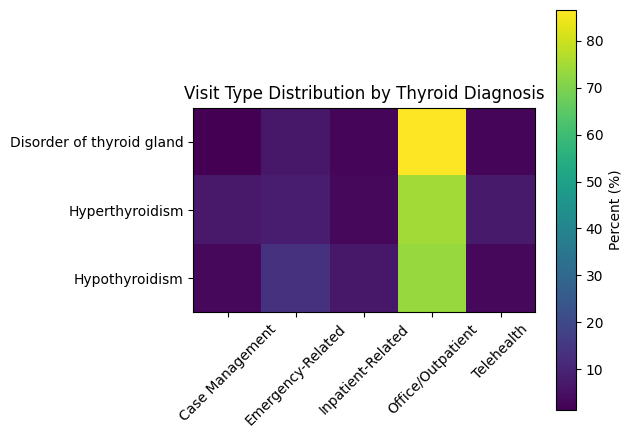

In [28]:
# Create a Heatmap to display results
plt.imshow(percent_contingency_table, aspect = 'equal')
plt.colorbar(label = "Percent (%)")

plt.xticks(
    range(len(percent_contingency_table.columns)),
    percent_contingency_table_display.columns,
    rotation = 45
)

plt.yticks(
    range(len(percent_contingency_table.index)),
    percent_contingency_table_display.index
)

plt.title("Visit Type Distribution by Thyroid Diagnosis")

plt.tight_layout()
plt.show()

## Matplotlib: Visit Type Distribution by Thyroid Diagnosis Bar Graph
- We used matplotlib to plot the desired data
- We'll plot:
    - A bar graph to display the visit type distribution by thyroid diagnosis

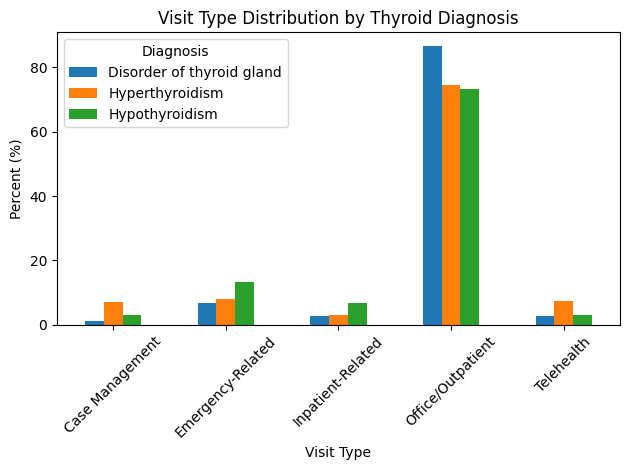

In [29]:
# Create a bar graph
percent_contingency_table.T.plot(kind = "bar")

plt.title("Visit Type Distribution by Thyroid Diagnosis")
plt.xlabel("Visit Type")
plt.ylabel("Percent (%)")

plt.xticks(rotation = 45)
plt.legend(title = "Diagnosis")

plt.tight_layout()
plt.show()

## **Narrative for Question 1B: Are certain thyroid diagnosis more likely to appear in specific visit types?**

### Objective:
- Find if there's specific thyroid diagnosis that are more likely to appear in specific visit types than others

### CSV files used:
- Used 1 csv file for this question: `visits_analysis_ready.csv`

### Approach Taken:
1. Create a contingency table to figure out the frequency of each thyroid-related diagnosis in each visit type
    - Will provide the percent distribution of thyroid diagnosis across the various visit types
2. Create a Heatmap and a Bar Graph to properly visualize our findings

### Findings:

After creating a contingency table, we can see that a large portion of thyroid-related cases make up the "office/outpatient" visit type. The diagnosis for "Disorder of the Thyroid Gland" make up 87% of the "office/outpatient" visits. While, "Hyperthyroidism" and "Hypothyroidism" both have a similar frequency rates of 74% in the same visit type. In addition, the "emergency-related" visits have a 13% rate of "Hypothyroidism" diagnosis compared to the other visit types. 

These results are further validated in both the visit type distribution by thyroid diagnosis heatmap and bar graph. We can see that a large percent of thyroid diagnosis are made in "office/outpatient" care settings (which is displayed by a bright yellow color), and the most common diagnosis in this care setting is the "Disorder of the Thyroid Gland". However, as stated before, both "Hyperthyroidism" and "Hypothyroidism" still have abnormally elevated percentages in the same care setting (the lower percent areas are those displayed in darker purple colors).

The heatmap and bar graph suggests that most thyroid-related care happens more often in office/outpatient visits, which can indicate that the diagnosis is frequently managed in this visit type. This can be due to the fact that most thyroid conditions are chronic but manageable if one is consistent with their treatment plans. Therefore, most thryoid-related care is not commonly diagnosed or treated in emergency and hospitilization related care. There is a slightly elevated percentage of hypothyroidism diagnosis that are seen in emergency-related settings and hyperthyroidism in telehealth. However, the percentage of these care settings are not as extremely pronounced as those seen in the office/outpatient care setting.